
**M.Talha Ramzan**
---
2330-0141
---
BS Ai
---
lab 03
---
KNN



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [5]:
df = pd.read_excel("/content/Iris.xlsx")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
# Check missing values
print(df.isnull().sum())

if "Id" in df.columns:
    df = df.drop("Id", axis=1)


X = df.drop("Species", axis=1)
y = df["Species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Features shape: (150, 4)
Target shape: (150,)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (120, 4)
Testing data size: (30, 4)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-1.72156775, -0.32483982, -1.34703555, -1.32016847],
       [-1.12449223, -1.22612948,  0.41429037,  0.65186742],
       [ 1.14439475, -0.55016223,  0.58474127,  0.25746024],
       [-1.12449223,  0.12580502, -1.29021859, -1.45163753],
       [-0.40800161, -1.22612948,  0.13020555,  0.12599118]])

In [11]:
k_values = [3, 5, 7]


results = {}

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results[k] = {
        "model": knn,
        "y_pred": y_pred,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1
    }

for k in k_values:
    print(f"\nK = {k}")
    print(f"Accuracy : {results[k]['accuracy']:.4f}")
    print(f"Precision: {results[k]['precision']:.4f}")
    print(f"Recall   : {results[k]['recall']:.4f}")
    print(f"F1 Score : {results[k]['f1_score']:.4f}")


K = 3
Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1 Score : 0.9327

K = 5
Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1 Score : 0.9327

K = 7
Accuracy : 0.9667
Precision: 0.9697
Recall   : 0.9667
F1 Score : 0.9666


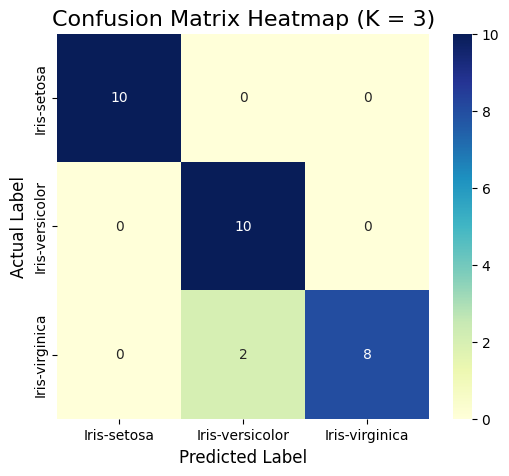

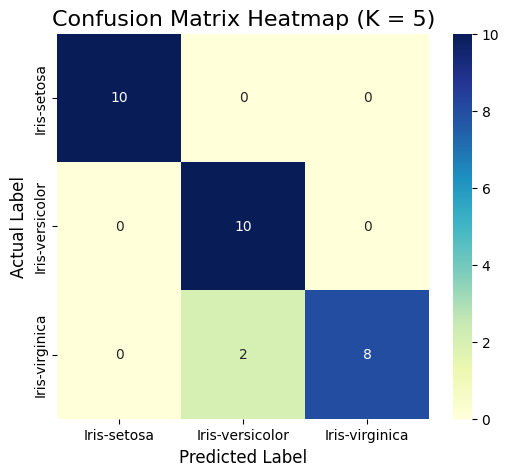

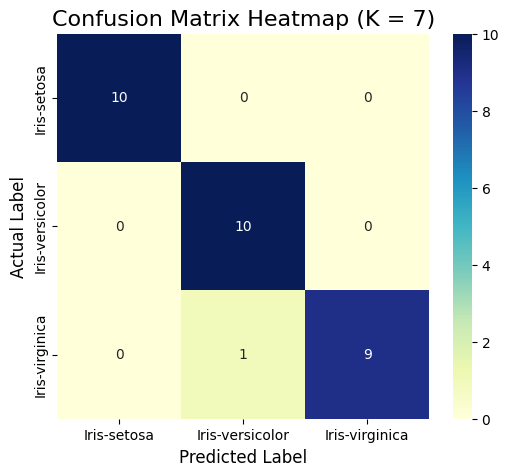

In [13]:
from sklearn.metrics import confusion_matrix

for k in k_values:
    cm = confusion_matrix(y_test, results[k]["y_pred"])

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=True,
                xticklabels=df['Species'].unique(),
                yticklabels=df['Species'].unique())

    plt.title(f"Confusion Matrix Heatmap (K = {k})", fontsize=16)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("Actual Label", fontsize=12)
    plt.show()

First, we imported the necessary libraries such as pandas, numpy, sklearn, and seaborn to prepare the tools for data handling, model training, and visualization. Next, we preprocessed the dataset by removing the Id column and separating the features (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm) and the target (Species). The data was then split into training and testing sets with 80% for training and 20% for testing. After that, the features were standardized using StandardScaler to ensure accurate predictions for the distance-based KNN model. We then trained KNN models with different k values (3, 5, 7) and evaluated their performance using accuracy, precision, recall, F1 score, and the confusion matrix. The confusion matrix analysis showed that the Setosa and Versicolor classes were perfectly predicted, while Virginica had a few misclassifications, which slightly improved at a higher k value (K=7). Finally, we used heatmap visualizations to clearly represent the model’s performance, showing that the KNN model performed very well on the Iris dataset overall.